## Project 

Dataset and processing: 

In [3]:
import pandas as pd

df = pd.read_csv("TMDB_female_representation.csv")
df.shape         
df.head()        
df.info()        
df.describe()   
df["representation_tier"].value_counts()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20070 entries, 0 to 20069
Data columns (total 55 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tmdb_id                20070 non-null  int64  
 1   title                  20070 non-null  object 
 2   release_date           20070 non-null  object 
 3   release_year           20070 non-null  int64  
 4   decade                 20070 non-null  int64  
 5   overview               20070 non-null  object 
 6   popularity             20070 non-null  float64
 7   budget                 20070 non-null  int64  
 8   revenue                20070 non-null  int64  
 9   runtime                20070 non-null  int64  
 10  vote_average           20070 non-null  float64
 11  vote_count             20070 non-null  int64  
 12  original_language      20070 non-null  object 
 13  genre_names            20070 non-null  object 
 14  primary_country        20070 non-null  object 
 15  pr

representation_tier
moderate    9242
weak        6236
strong      4592
Name: count, dtype: int64

## How tiers were determined: 
- Strong: the film has a female lead and at least one of these is also true: the director is female, or at least 50% of the top 5 cast are women. Basically female representation both in front of and behind the camera.
- Moderate: the film has a female lead or a female director or at least 40% of the top 5 cast are women. At least one meaningful signal of female representation exists, but not enough to be "strong."
- Weak: none of the above. Male lead, male director, and less than 40% of the top 5 cast are women.

In [5]:
import pandas as pd

df = pd.read_csv("tmdb_female_representation.csv")

print(f"Records:  {len(df)}")
print(f"Features: {len(df.columns)}")

print(f"\nClass Distribution:")
counts = df["representation_tier"].value_counts()
for tier, count in counts.items():
    print(f"  {tier:10s}: {count} ({100*count/len(df):.1f}%)")

print(f"\nFeature Types:")
print(f"  Numeric:     {len(df.select_dtypes(include='number').columns)}")
print(f"  Categorical: {len(df.select_dtypes(include='object').columns)}")

print(f"\nMissing Data:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
for col, count in missing.items():
    print(f"  {col:30s}: {count} ({100*count/len(df):.1f}%)")

print(f"\nYear Range: {int(df['release_year'].min())} – {int(df['release_year'].max())}")

Records:  20070
Features: 55

Class Distribution:
  moderate  : 9242 (46.0%)
  weak      : 6236 (31.1%)
  strong    : 4592 (22.9%)

Feature Types:
  Numeric:     45
  Categorical: 10

Missing Data:

Year Range: 2005 – 2024


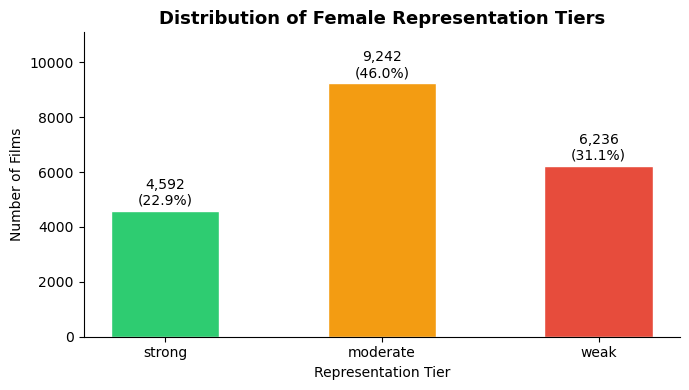

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plotting the class distribution
fig, ax = plt.subplots(figsize=(7, 4))
order = ["strong", "moderate", "weak"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
counts = df["representation_tier"].value_counts()[order]
bars = ax.bar(order, counts, color=colors, edgecolor="white", width=0.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{count:,}\n({100*count/len(df):.1f}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_title("Distribution of Female Representation Tiers", fontsize=13, fontweight="bold")
ax.set_xlabel("Representation Tier")
ax.set_ylabel("Number of Films")
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

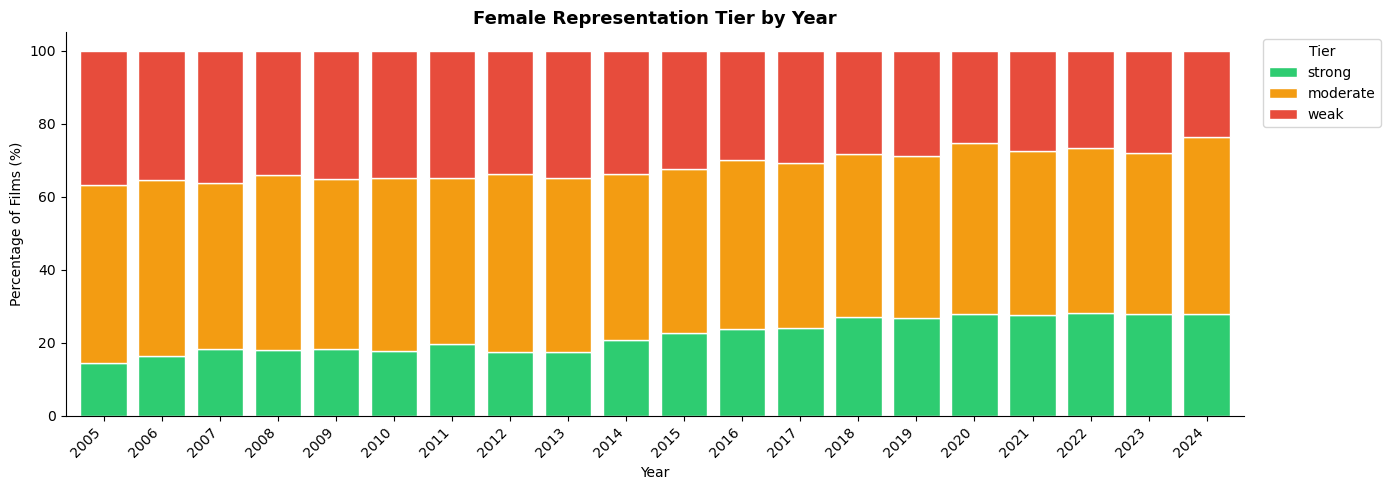

In [7]:
# Representation Tier by Year
year_tier = df.groupby(["release_year", "representation_tier"]).size().unstack(fill_value=0)
year_tier_pct = year_tier.div(year_tier.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
year_tier_pct[["strong", "moderate", "weak"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#2ecc71", "#f39c12", "#e74c3c"],
    edgecolor="white", width=0.8
)
ax.set_title("Female Representation Tier by Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage of Films (%)")
ax.legend(title="Tier", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels([str(int(y)) for y in year_tier_pct.index], rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

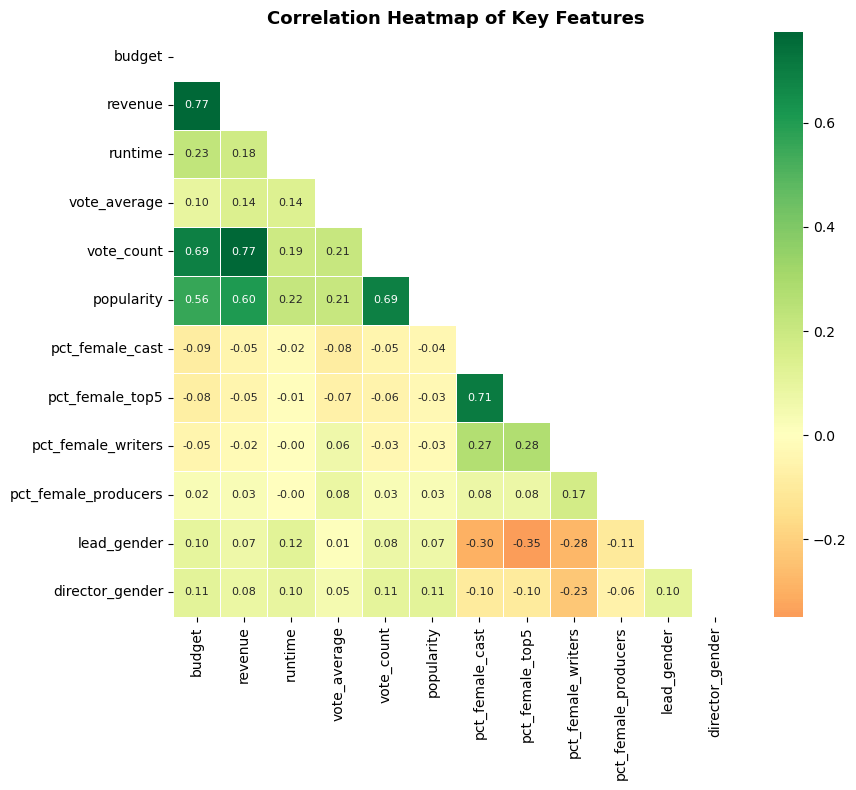

In [8]:
# Correlation Heatmap of Key Numeric Features

key_numeric = [
    "budget", "revenue", "runtime", "vote_average", "vote_count",
    "popularity", "pct_female_cast", "pct_female_top5",
    "pct_female_writers", "pct_female_producers",
    "lead_gender", "director_gender"
]
key_numeric = [c for c in key_numeric if c in df.columns]

fig, ax = plt.subplots(figsize=(9, 8))
corr = df[key_numeric].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 8})
ax.set_title("Correlation Heatmap of Key Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

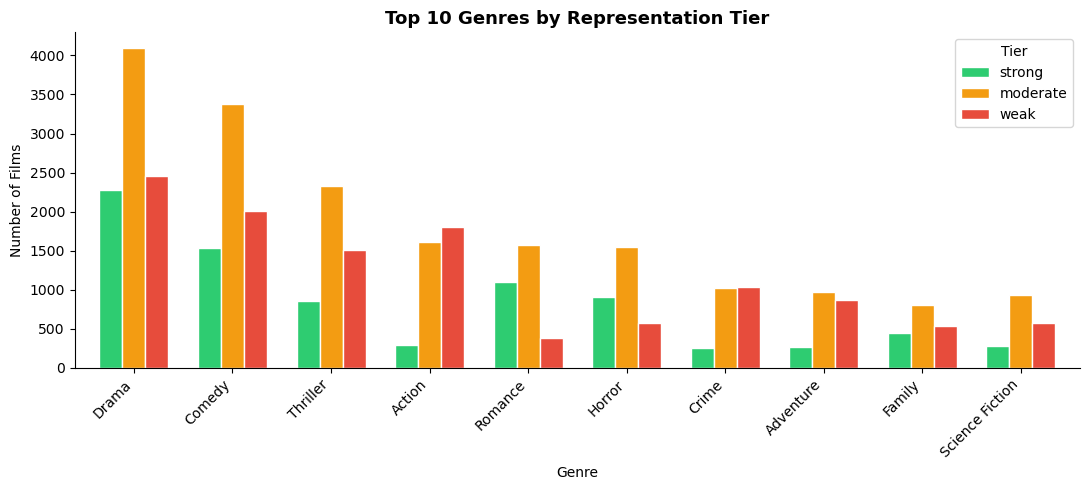

In [9]:
# Top Genres by Representation Tier
from collections import defaultdict

# Parse genre_names column directly instead of using dummy cols
genre_counts = defaultdict(lambda: {"strong": 0, "moderate": 0, "weak": 0})

for _, row in df.iterrows():
    if pd.isna(row["genre_names"]):
        continue
    for genre in row["genre_names"].split("|"):
        genre = genre.strip()
        if genre:
            genre_counts[genre][row["representation_tier"]] += 1

genre_df = pd.DataFrame(genre_counts).T
genre_df["total"] = genre_df.sum(axis=1)
top10 = genre_df.nlargest(10, "total")[["strong", "moderate", "weak"]]

fig, ax = plt.subplots(figsize=(11, 5))
top10.plot(kind="bar", ax=ax,
           color=["#2ecc71", "#f39c12", "#e74c3c"],
           edgecolor="white", width=0.7)
ax.set_title("Top 10 Genres by Representation Tier", fontsize=13, fontweight="bold")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Films")
ax.legend(title="Tier")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

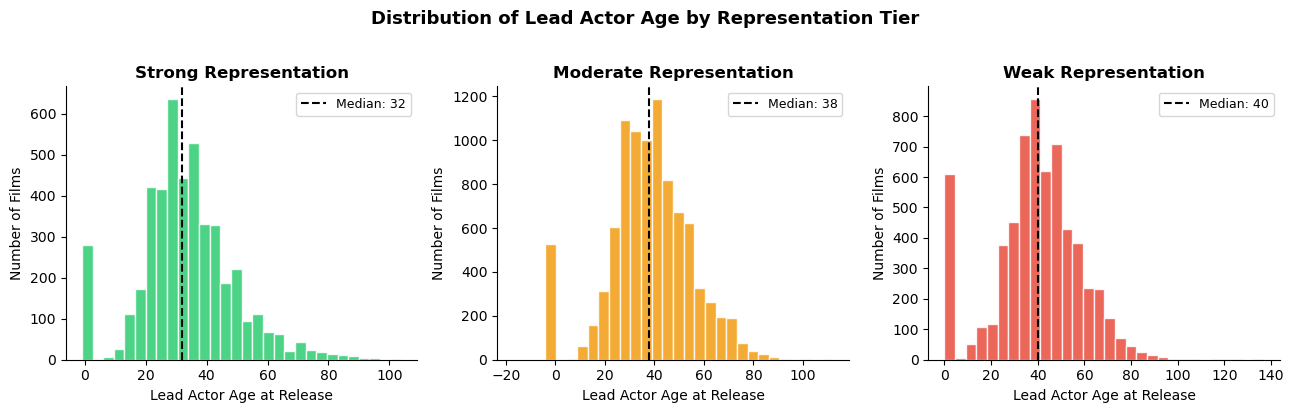

In [10]:
# Distribution of Lead Actor Age by Representation Tier
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
order = ["strong", "moderate", "weak"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

for ax, tier, color in zip(axes, order, colors):
    tier_data = df[df["representation_tier"] == tier]["lead_actor_age"].dropna()
    ax.hist(tier_data, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(tier_data.median(), color="black", linestyle="--", linewidth=1.5,
               label=f"Median: {tier_data.median():.0f}")
    ax.set_title(f"{tier.capitalize()} Representation", fontweight="bold")
    ax.set_xlabel("Lead Actor Age at Release")
    ax.set_ylabel("Number of Films")
    ax.legend(fontsize=9)
    sns.despine()

plt.suptitle("Distribution of Lead Actor Age by Representation Tier",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Label encoding: {'moderate': 0, 'strong': 1, 'weak': 2}
Features used: 31
Dataset size after dropping NaN: 20070 rows

Train: 16056 | Test: 4014

Classification Report:
              precision    recall  f1-score   support

    moderate       0.54      0.24      0.33      1849
      strong       0.37      0.70      0.48       918
        weak       0.49      0.57      0.52      1247

    accuracy                           0.45      4014
   macro avg       0.47      0.50      0.44      4014
weighted avg       0.49      0.45      0.42      4014

5-Fold CV Macro F1: 0.3111 (+/- 0.1029)


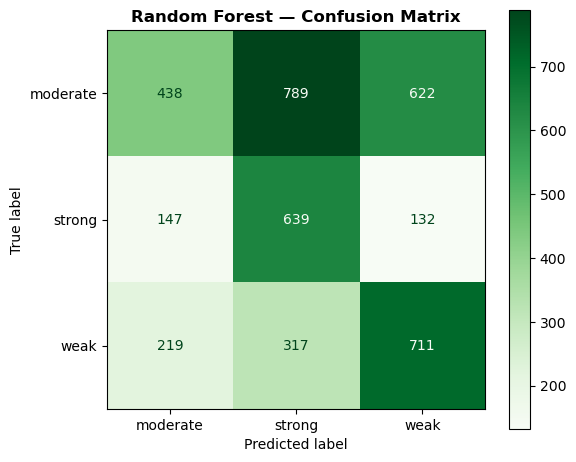

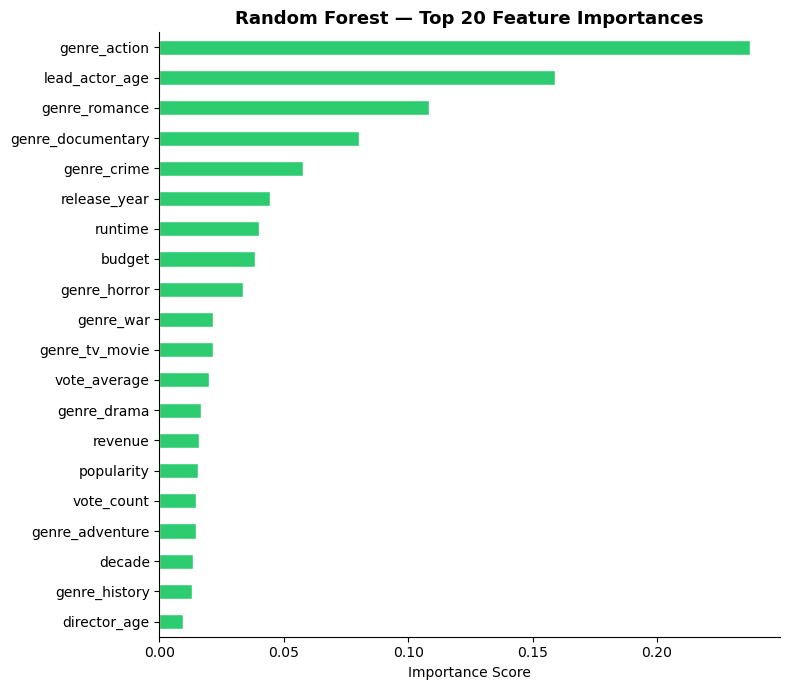

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Select features

# Ensure genre dummy columns are numeric
genre_cols = [c for c in df.columns if c.startswith("genre_")]
for col in genre_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# Columns to explicitly exclude (strings, identifiers, and
# any gender composition features used to build the label)
exclude = [
    "tmdb_id", "title", "release_date", "overview", "genre_names",
    "primary_country", "primary_company", "original_language",
    "lead_actor_name", "director_name", "representation_tier",
    "tagline", "popularity_detail",
    # REMOVE: these were used to construct the label — data leakage
    "lead_gender", "director_gender",
    "pct_female_top5", "pct_female_cast",
    "pct_female_writers", "pct_female_producers",
    "cast_female", "cast_male", "cast_total_known",
    "top5_female", "top5_male",
    "female_writers", "female_producers",
]

# Only use production & commercial metadata as predictors
feature_cols = [
    "budget", "revenue", "runtime",
    "vote_average", "vote_count", "popularity",
    "language_count", "num_directors",
    "lead_actor_age", "director_age",
    "release_year", "decade"
] + genre_cols

# Keep only columns that exist and aren't excluded
feature_cols = [c for c in feature_cols if c in df.columns and c not in exclude]

# Drop rows with NaN in features or label
model_df = df[feature_cols + ["representation_tier"]].dropna()

X = model_df[feature_cols]
y = model_df["representation_tier"]

# Encode label
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))
print(f"Features used: {len(feature_cols)}")
print(f"Dataset size after dropping NaN: {len(model_df)} rows")


# Train Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")


# Training

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,        # reduce from 10
    min_samples_leaf=10, # require more samples per leaf
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)


# Evaluation

y_pred = rf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# K-fold cross validation
cv_scores = cross_val_score(rf, X, y_encoded, cv=5, scoring="f1_macro")
print(f"5-Fold CV Macro F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


# Plot Confusion Matrix

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap="Greens", ax=ax
)
ax.set_title("Random Forest — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

# Plot feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
top20.plot(kind="barh", ax=ax, color="#2ecc71", edgecolor="white")
ax.set_title("Random Forest — Top 20 Feature Importances", fontweight="bold", fontsize=13)
ax.set_xlabel("Importance Score")
sns.despine()
plt.tight_layout()
plt.show()

## Kernel SVM Model

Classification Report:
              precision    recall  f1-score   support

    moderate       0.56      0.34      0.42      1849
      strong       0.39      0.62      0.47       918
        weak       0.51      0.57      0.54      1247

    accuracy                           0.48      4014
   macro avg       0.48      0.51      0.48      4014
weighted avg       0.50      0.48      0.47      4014

5-Fold CV Macro F1: 0.4183 (+/- 0.0636)


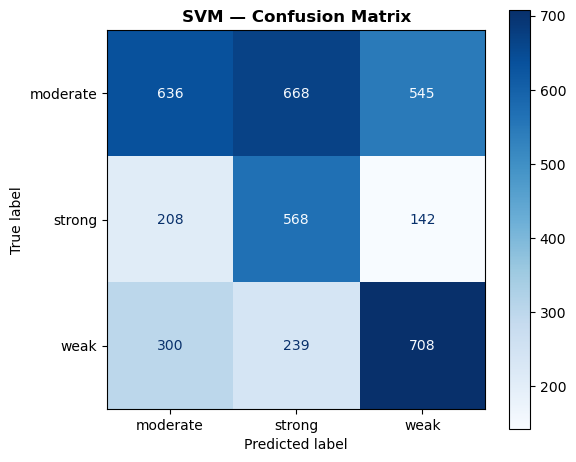

In [14]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse same feature_cols, X, y_encoded, splits from RF
# X_train, X_test, y_train, y_test, le, feature_cols
# are all already defined from the Random Forest cell above

# Training SVM
# SVM requires feature scaling, we will use StandardScaler in a Pipeline

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42,
        decision_function_shape="ovr"
    ))
])

svm_pipeline.fit(X_train, y_train)


# Evaluation

y_pred_svm = svm_pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# K-fold cross validation
cv_scores_svm = cross_val_score(svm_pipeline, X, y_encoded, cv=5, scoring="f1_macro")
print(f"5-Fold CV Macro F1: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std():.4f})")


# Confusion Matrix

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=le.classes_,
    cmap="Blues", ax=ax
)
ax.set_title("SVM — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()
